# Shared Significant-Gene GO Test (Single Pooled Plot)

This notebook now uses a single pooled analysis:

1. Get significant genes per subtype first (`pvalue < 0.05` and `|log2FC| > 1`).
2. Intersect those significant sets across subtypes.
3. Run GO enrichment once on that shared-significant gene list.
4. Plot one combined figure (BP/CC/MF).

In [1]:
import sys
sys.path.append("../src")
import matplotlib.pyplot as plt
import seaborn as sns
import importlib
import pandas as pd
import GOenrichment as ge

importlib.reload(ge)

files = {
    "Proneural": "../data/interim/proneural_rna_diff.csv",
    "Classical": "../data/interim/classical_rna_diff.csv",
    "Mesenchymal": "../data/interim/mesenchymal_rna_diff.csv",
}

PVAL = ge.PVAL_COLUMN
LOGFC = ge.LOGFC_COLUMN
GENE = ge.GENE_COLUMN

In [2]:
sig_up_sets = {}
sig_down_sets = {}

for subtype, file in files.items():
    df = pd.read_csv(file)

    up = df[
        (df[PVAL] < ge.PVAL_THRESHOLD)
        &
        (df[LOGFC] > ge.LOGFC_THRESHOLD)
    ]
    down = df[
        (df[PVAL] < ge.PVAL_THRESHOLD)
        &
        (df[LOGFC] < -ge.LOGFC_THRESHOLD)
    ]

    sig_up_sets[subtype] = set(up[GENE].dropna().str.upper())
    sig_down_sets[subtype] = set(down[GENE].dropna().str.upper())

shared_up_genes = set.intersection(*sig_up_sets.values())
shared_down_genes = set.intersection(*sig_down_sets.values())

print("Shared upregulated significant genes per subtype:", {k: len(v) for k, v in sig_up_sets.items()})
print("Shared downregulated significant genes per subtype:", {k: len(v) for k, v in sig_down_sets.items()})
print("Shared upregulated genes across all subtypes:", len(shared_up_genes))
print("Shared downregulated genes across all subtypes:", len(shared_down_genes))

Shared upregulated significant genes per subtype: {'Proneural': 1860, 'Classical': 2039, 'Mesenchymal': 2263}
Shared downregulated significant genes per subtype: {'Proneural': 1557, 'Classical': 1728, 'Mesenchymal': 1808}
Shared upregulated genes across all subtypes: 1601
Shared downregulated genes across all subtypes: 1404


Combined shared-significant genes: 3005
Shared up genes: 1601
Shared down genes: 1404


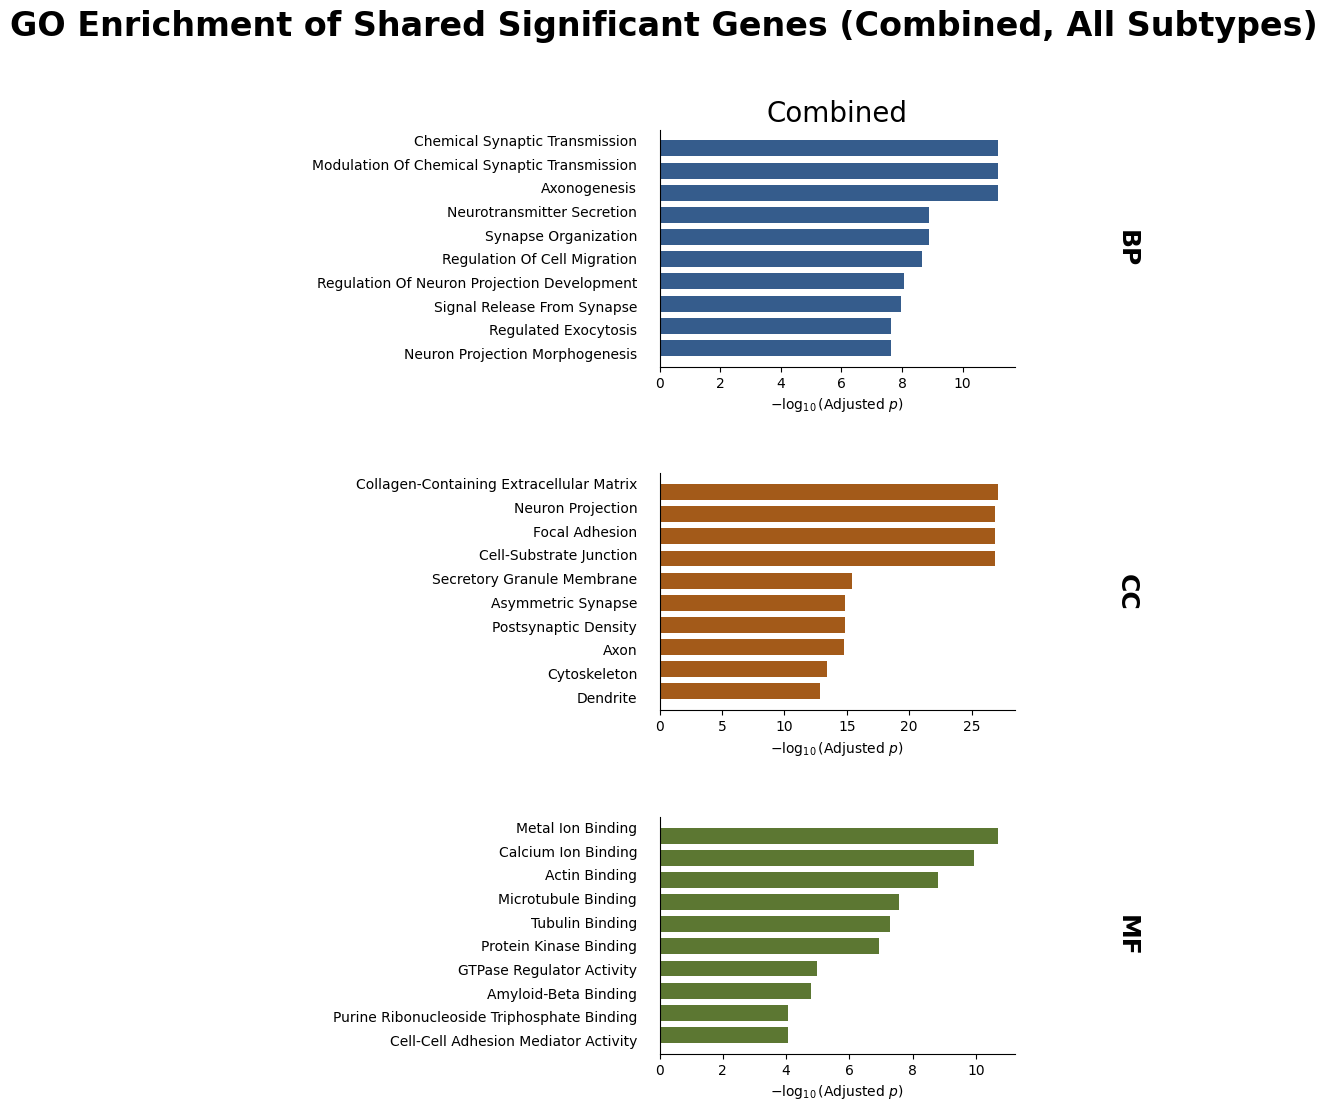

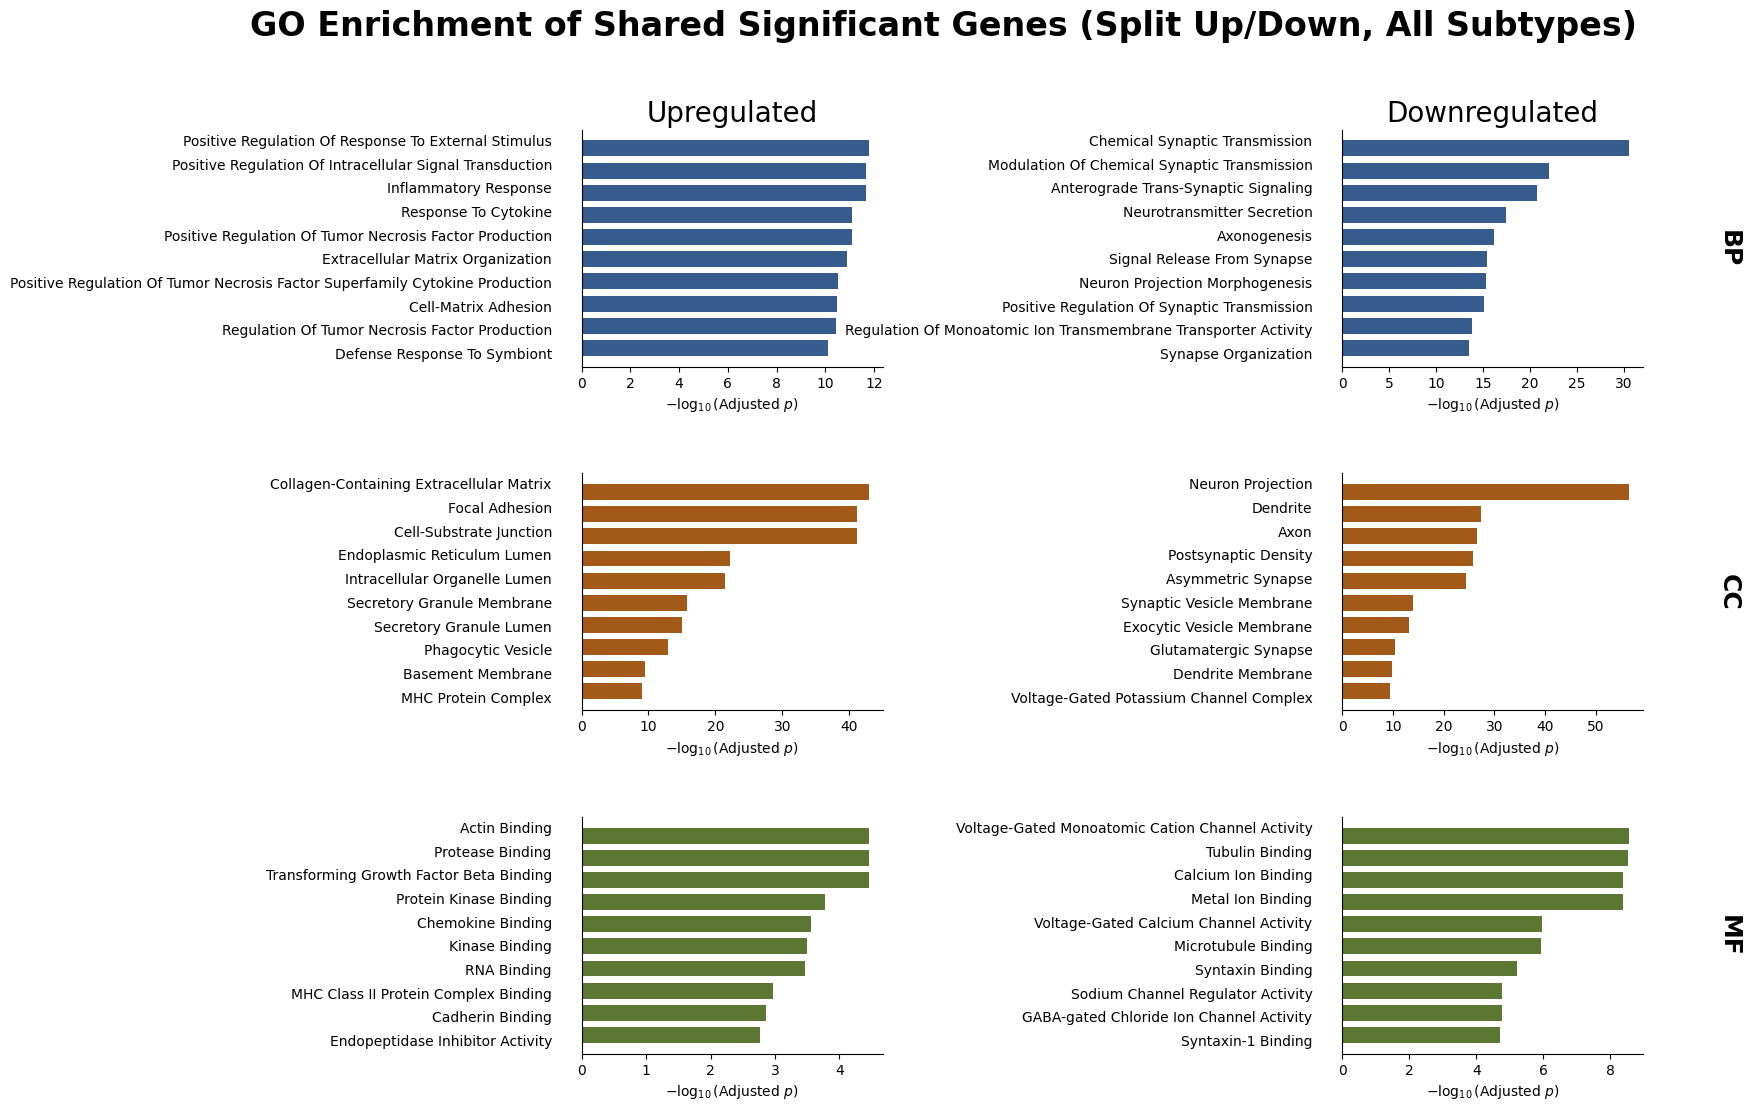

In [3]:
go_combined = {}
go_up = {}
go_down = {}

combined_genes = sorted(shared_up_genes | shared_down_genes)
up_genes = sorted(shared_up_genes)
down_genes = sorted(shared_down_genes)

print("Combined shared-significant genes:", len(combined_genes))
print("Shared up genes:", len(up_genes))
print("Shared down genes:", len(down_genes))

for ontology, library in ge.GO_LIBRARIES.items():
    go_combined[ontology] = ge.run_go(combined_genes, library)
    go_up[ontology] = ge.run_go(up_genes, library)
    go_down[ontology] = ge.run_go(down_genes, library)

ge.plot_go(
    go_combined,
    title="GO Enrichment of Shared Significant Genes (Combined, All Subtypes)",
)

ge.plot_go(
    go_up,
    go_down,
    title="GO Enrichment of Shared Significant Genes (Split Up/Down, All Subtypes)",
)

In [4]:
bp = go_combined["BP"].copy()

top3 = bp.head(3)

bp_matrices = {}

for _, row in top3.iterrows():

    term = row["Term"]
    genes = [g.upper() for g in row["Genes"].split(";")]

    # Collect log2FC for every subtype
    fc = pd.DataFrame(index=files.keys(), columns=genes, dtype=float)

    for subtype, file in files.items():

        df = pd.read_csv(file)

        df["gene_upper"] = df[GENE].str.upper()
        df = df.set_index("gene_upper")

        for gene in genes:

            if gene in df.index:
                fc.loc[subtype, gene] = df.loc[gene, LOGFC]

    # Keep the 10 genes with the largest absolute log2FC
    score = fc.abs().max(axis=0).sort_values(ascending=False)

    fc = fc[score.index]

    bp_matrices[term] = fc

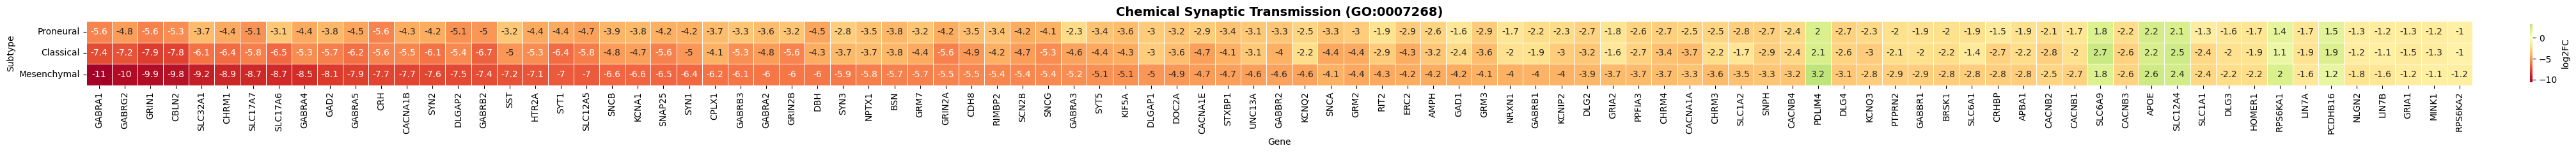

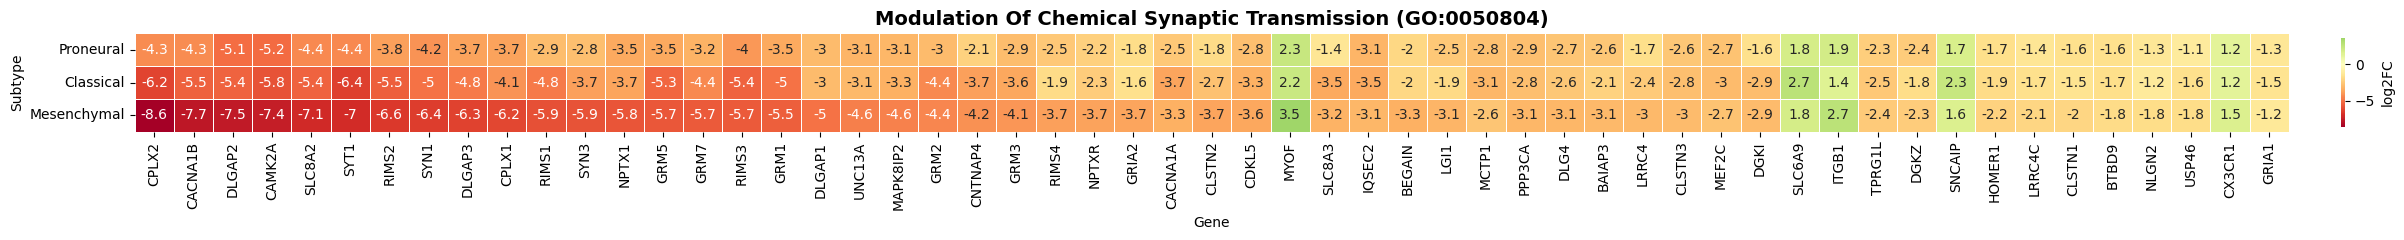

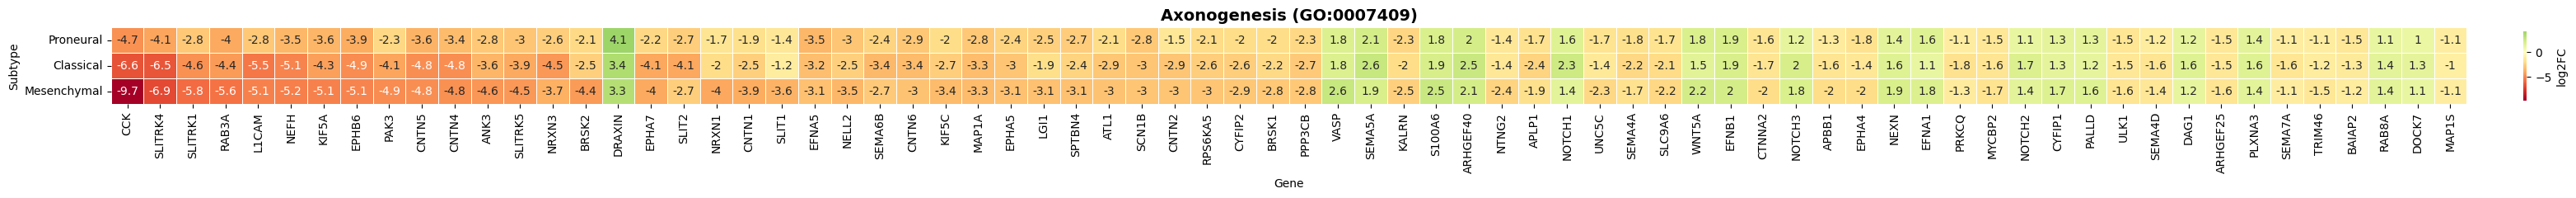

In [5]:

for term, matrix in bp_matrices.items():

    plt.figure(figsize=(max(8, len(matrix.columns) * 0.5), 2.5))

    sns.heatmap(
    matrix,
    cmap="RdYlGn",
    center=0,
    annot = True,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={
        "label": "log2FC",
        "pad": 0.02,
        "shrink": 0.9
    }
)

    plt.title(term, fontsize=14, fontweight="bold")
    plt.xlabel("Gene")
    plt.ylabel("Subtype")

    plt.xticks(rotation=90)
    plt.yticks(rotation=0)

    plt.tight_layout()
    plt.show()

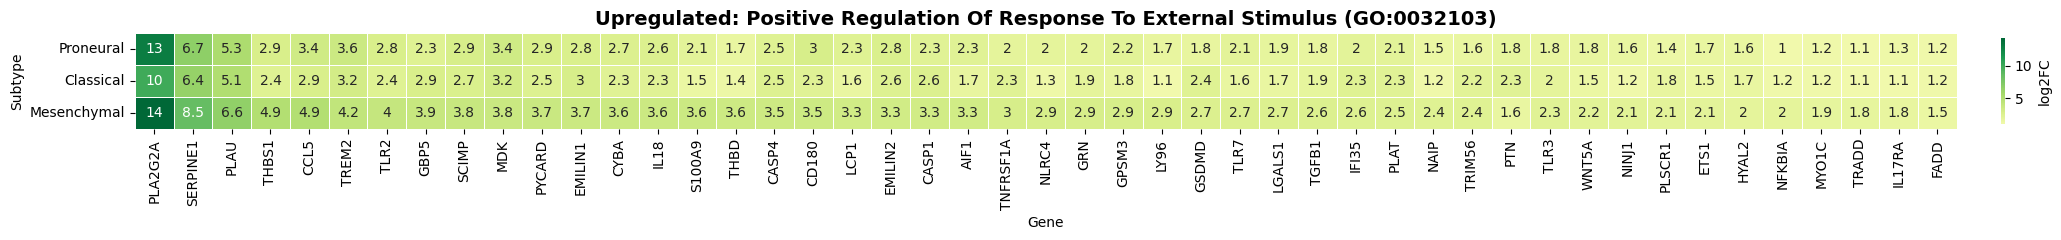

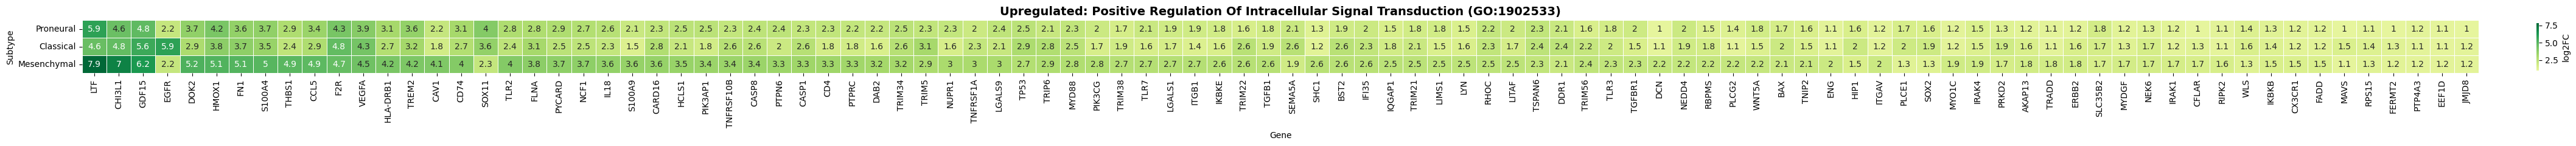

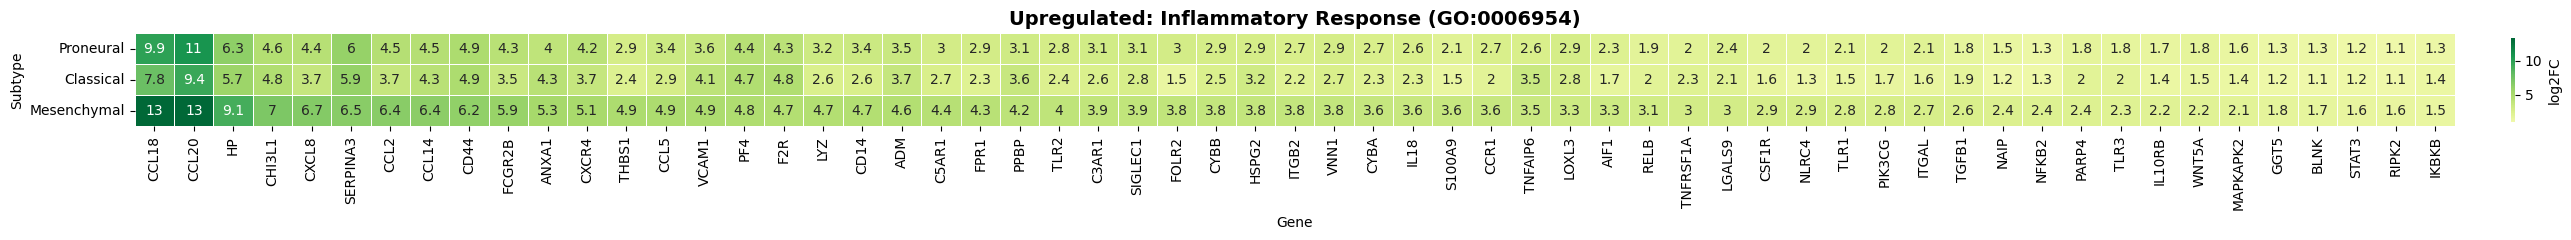

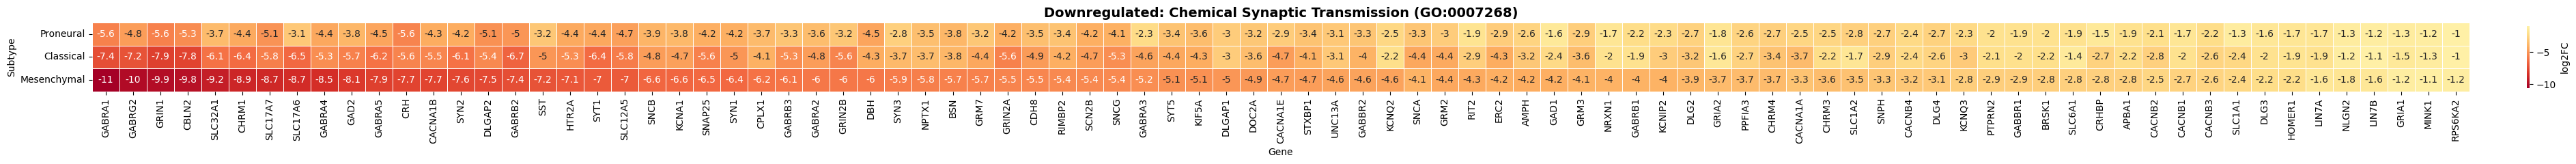

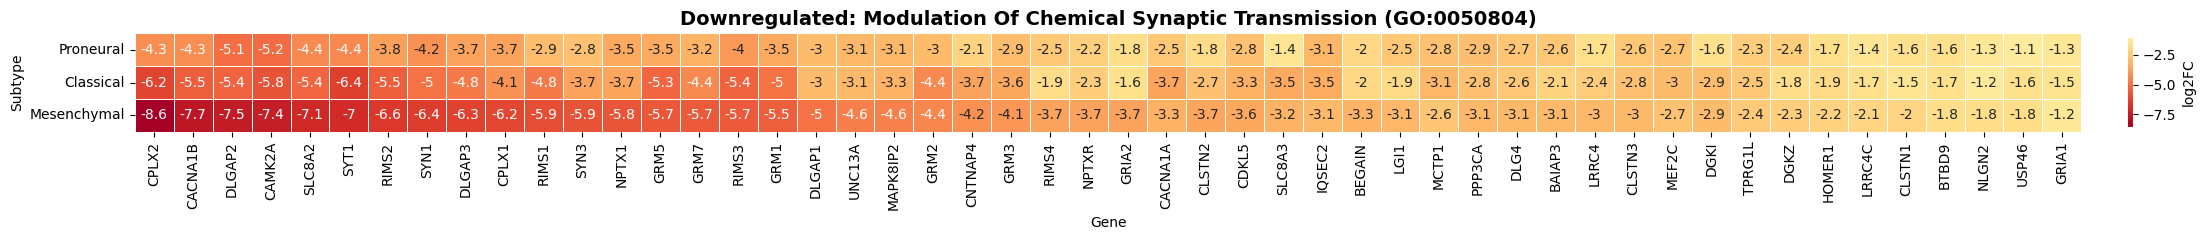

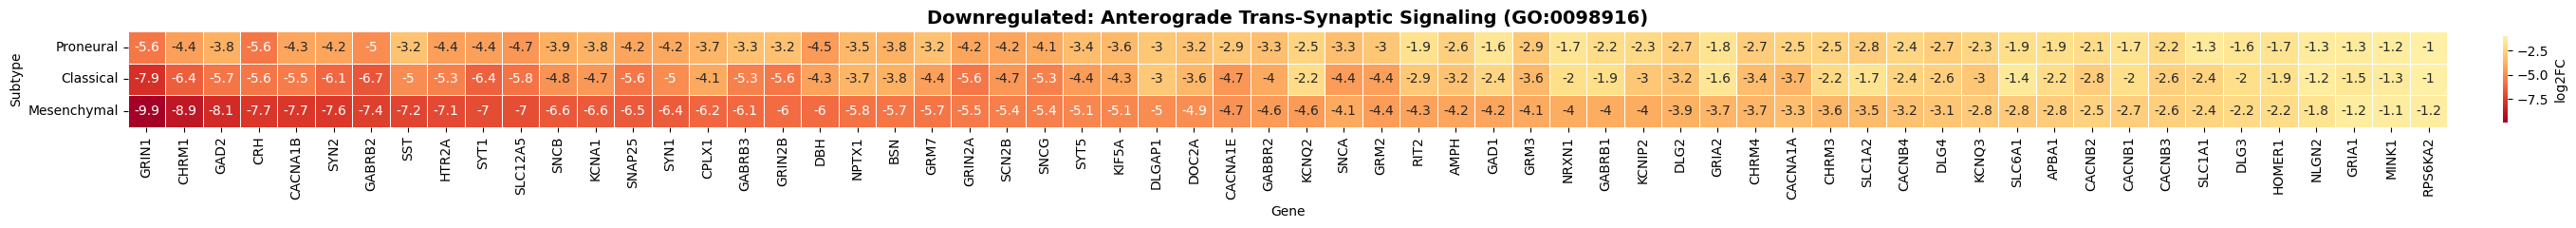

In [6]:
bp_sets = {
    "Upregulated": go_up["BP"],
    "Downregulated": go_down["BP"]
}

for direction, bp in bp_sets.items():

    top3 = bp.head(3)

    bp_matrices = {}

    for _, row in top3.iterrows():

        term = row["Term"]
        genes = [g.upper() for g in row["Genes"].split(";")]

        fc = pd.DataFrame(
            index=files.keys(),
            columns=genes,
            dtype=float
        )

        for subtype, file in files.items():

            df = pd.read_csv(file)

            df["gene_upper"] = df[GENE].str.upper()
            df = df.set_index("gene_upper")

            for gene in genes:

                if gene in df.index:
                    fc.loc[subtype, gene] = df.loc[gene, LOGFC]

        # Keep top 10 genes by |log2FC|
        score = fc.abs().max(axis=0).sort_values(ascending=False)
        fc = fc[score.index]

        bp_matrices[term] = fc

    # Plot
    for term, matrix in bp_matrices.items():

        plt.figure(figsize=(max(8, len(matrix.columns) * 0.5), 2.5))

        sns.heatmap(
    matrix,
    cmap="RdYlGn",
    center=0,
    linewidths=0.5,
    linecolor="white",
    annot = True,
    cbar_kws={
        "label": "log2FC",
        "pad": 0.02,
        "shrink": 0.9
    }
)

        plt.title(f"{direction}: {term}", fontsize=14, fontweight="bold")
        plt.xlabel("Gene")
        plt.ylabel("Subtype")

        plt.xticks(rotation=90)
        plt.yticks(rotation=0)

        plt.tight_layout()
        plt.show()